**Disciplina: Aprendizagem de Máquina**

Período: 2025.2 e 2026.1

Professor: César Lincoln Cavalcante Mattos

Aluno: José Wilson Aguiar Júnior

**Lista 3 - MLP, SVM e ensembles**


**Instruções**


*   Algoritmos e modelos de implementações já existentes (e.g. scikit-learn) podem ser usados;

*   Use de prints, gráficos e tabelas para apresentar o ajuste dos modelos e os
resultados obtidos;

*   Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.

In [2]:
#Fazendo o upload do arquivo vehicle.csv

from google.colab import files
uploaded = files.upload()

Saving vehicle.csv to vehicle.csv


In [3]:
# Importando o arquivo vehicle.csv

import pandas as pd

# Ler o arquivo
df = pd.read_csv('vehicle.csv')

# Exibir todas as colunas
print("Colunas do vehicle.csv:")
print(df.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do vehicle.csv:
['9.500000000000000000e+01', '4.800000000000000000e+01', '8.300000000000000000e+01', '1.780000000000000000e+02', '7.200000000000000000e+01', '1.000000000000000000e+01', '1.620000000000000000e+02', '4.200000000000000000e+01', '2.000000000000000000e+01', '1.590000000000000000e+02', '1.760000000000000000e+02', '3.790000000000000000e+02', '1.840000000000000000e+02', '7.000000000000000000e+01', '6.000000000000000000e+00', '1.600000000000000000e+01', '1.870000000000000000e+02', '1.970000000000000000e+02', '3.000000000000000000e+00']

Número de linhas: 845
Número de colunas: 19


**Questão 1**


Considere o conjunto de dados disponível em vehicle.csv, organizado em 19 colunas, sendo as 18 primeiras colunas os atributos e a última coluna a saída. Os 18 atributos caracterizam a silhueta de veículos, extraídos pelo método HIPS (Hierarchical Image Processing System). A tarefa consiste em classificar o  veículo em 4 classes (bus, opel, saab, e van). Maiores detalhes sobre os dados podem ser conferidos em https://www.openml.org/search?type=data&sort=runs&
id=54.

a) Considerando uma validação cruzada em 5 folds, avalie modelos de classificação multiclasse nos dados em questão. Para tanto, use as abordagens
abaixo:


*   Multilayer Perceptron;
*   SVM;
*   Random Forest;
*   Gradient Boosting.

Observação: Os hiperparâmetros dos modelos devem ser ajustados adequadamente.


ANÁLISE EXPLORATÓRIA DO DATASET

Dimensões: (845, 19)

Primeiras linhas:
   9.500000000000000000e+01  4.800000000000000000e+01  \
0                      91.0                      41.0   
1                     104.0                      50.0   
2                      93.0                      41.0   
3                      85.0                      44.0   
4                     107.0                      57.0   

   8.300000000000000000e+01  1.780000000000000000e+02  \
0                      84.0                     141.0   
1                     106.0                     209.0   
2                      82.0                     159.0   
3                      70.0                     205.0   
4                     106.0                     172.0   

   7.200000000000000000e+01  1.000000000000000000e+01  \
0                      57.0                       9.0   
1                      66.0                      10.0   
2                      63.0                       9.0   
3            

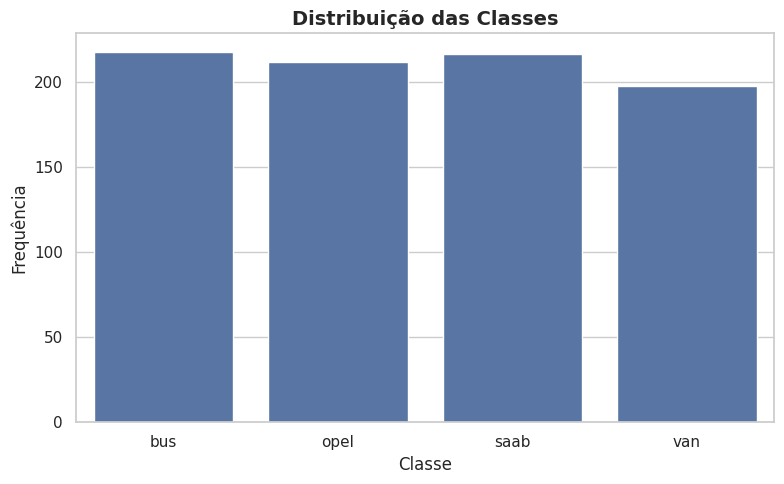


✓ Pré-processamento concluído
  Classes: ['bus' 'opel' 'saab' 'van']

VALIDAÇÃO CRUZADA (5 FOLDS) - MLP

Métricas por fold:

Accuracy:
  Fold 1: 0.5917
  Fold 2: 0.7101
  Fold 3: 0.6627
  Fold 4: 0.6923
  Fold 5: 0.7515
  Média: 0.6817 ± 0.0534

F1 Macro:
  Fold 1: 0.5740
  Fold 2: 0.6869
  Fold 3: 0.6460
  Fold 4: 0.6829
  Fold 5: 0.7421
  Média: 0.6664 ± 0.0555

Precision Macro:
  Fold 1: 0.5866
  Fold 2: 0.7056
  Fold 3: 0.6614
  Fold 4: 0.6766
  Fold 5: 0.7477
  Média: 0.6756 ± 0.0533

Recall Macro:
  Fold 1: 0.5959
  Fold 2: 0.7111
  Fold 3: 0.6663
  Fold 4: 0.6987
  Fold 5: 0.7591
  Média: 0.6862 ± 0.0541

TABELA RESUMO DAS MÉTRICAS
          Métrica    Média  Desvio Padrão
         Acurácia 0.681657       0.053373
 F1-Score (macro) 0.666375       0.055463
 Precisão (macro) 0.675597       0.053314
Revocação (macro) 0.686218       0.054121


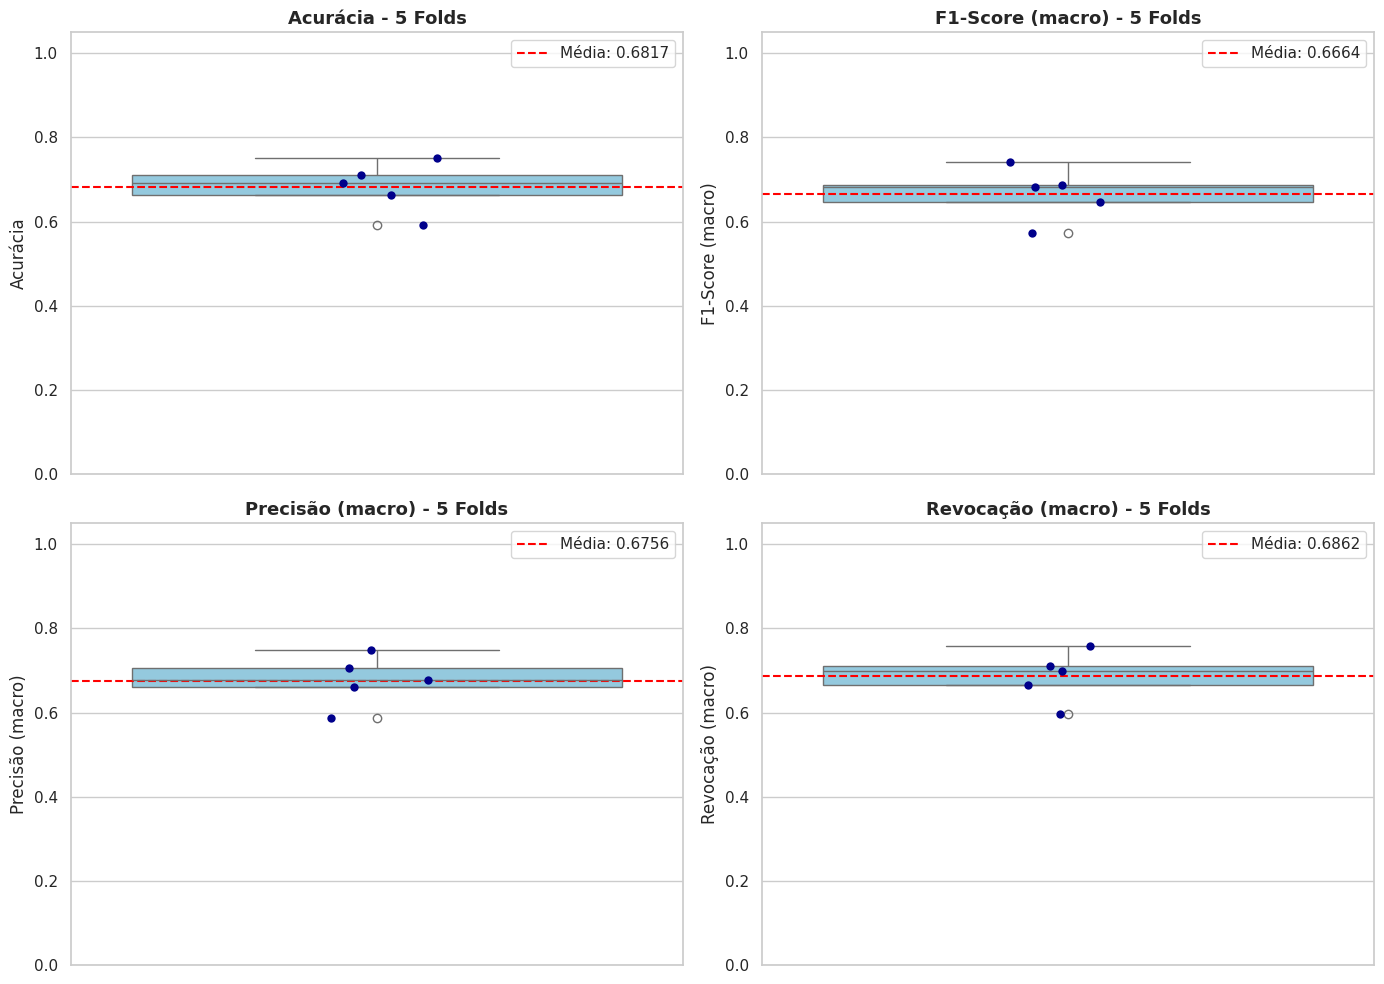

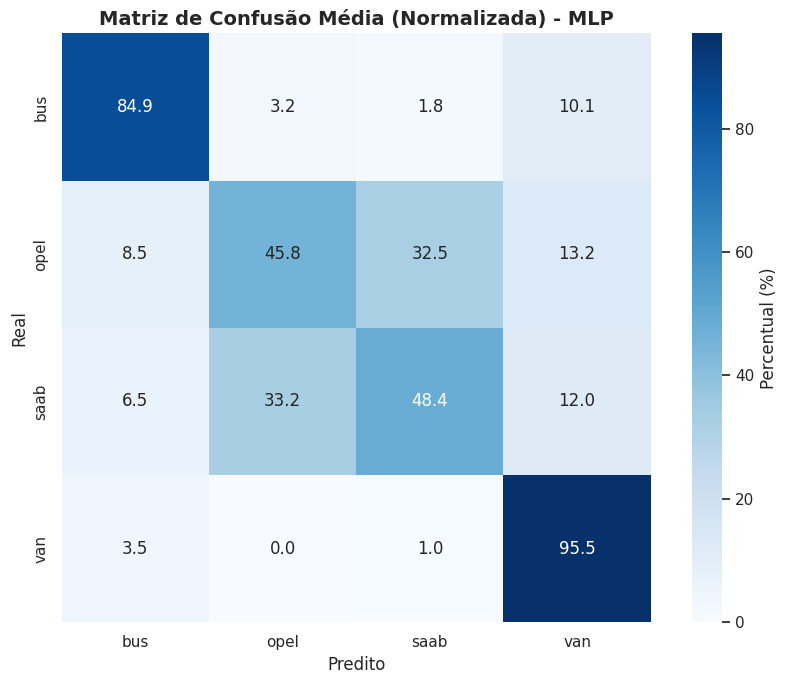


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

         bus       0.83      0.89      0.86       218
        opel       0.63      0.52      0.57       212
        saab       0.62      0.48      0.54       217
         van       0.71      0.95      0.81       198

    accuracy                           0.71       845
   macro avg       0.70      0.71      0.70       845
weighted avg       0.70      0.71      0.69       845



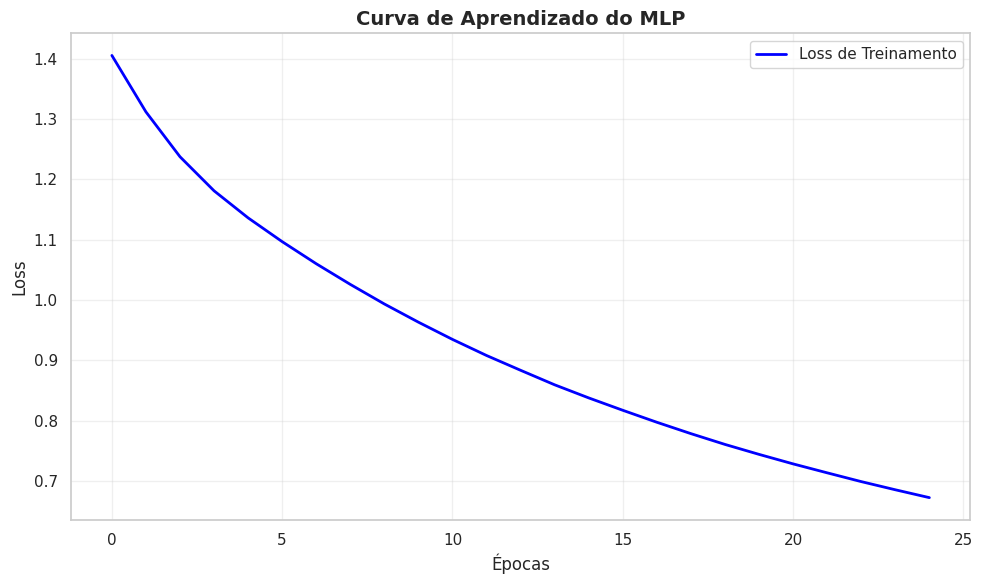


✓ Épocas de treinamento: 25
✓ Loss final: 0.672765
Melhor loss de validação não disponível


In [9]:
# ============================================
# Questão 1a - Classificação com MLP + Validação Cruzada (5 folds) Multilayer Perceptron
# Dataset: vehicle.csv (18 atributos, 4 classes)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# ============================================
# 1. Carregamento e Análise Exploratória
# ============================================

df = pd.read_csv('vehicle.csv')

print("="*60)
print("ANÁLISE EXPLORATÓRIA DO DATASET")
print("="*60)
print(f"\nDimensões: {df.shape}")
print(f"\nPrimeiras linhas:\n{df.head()}")
print(f"\nValores únicos na coluna alvo: {sorted(df.iloc[:, -1].unique())}")
print(f"Tipo da coluna alvo: {df.iloc[:, -1].dtype}")

# ============================================
# 2. Pré-processamento com Mapeamento Correto das Classes
# ============================================

# Separar features e target
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# Converter para inteiros e mapear para nomes descritivos
# Conforme documentação OpenML: 0=bus, 1=opel, 2=saab, 3=van
class_mapping = {0: 'bus', 1: 'opel', 2: 'saab', 3: 'van'}
y_int = y_raw.astype(int)
y_named = np.array([class_mapping[val] for val in y_int])

# Codificar para uso no modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y_named)
classes_descritivas = le.classes_

# Distribuição das classes
print("\nDistribuição das classes:")
dist = pd.Series(y_named).value_counts().sort_index()
print(dist)
print("\nProporção (%):")
print((dist / len(y_named) * 100).round(2))

# Visualização
plt.figure(figsize=(8, 5))
sns.countplot(x=y_named, order=sorted(classes_descritivas))
plt.title('Distribuição das Classes', fontsize=14, fontweight='bold')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✓ Pré-processamento concluído")
print(f"  Classes: {classes_descritivas}")

# ============================================
# 3. Validação Cruzada com MLP
# ============================================

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("VALIDAÇÃO CRUZADA (5 FOLDS) - MLP")
print("="*60)
cv_results = cross_validate(mlp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# Resultados por fold
print("\nMétricas por fold:")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    values = cv_results[metric]
    print(f"\n{metric.replace('test_', '').replace('_', ' ').title()}:")
    for i, val in enumerate(values, 1):
        print(f"  Fold {i}: {val:.4f}")
    print(f"  Média: {values.mean():.4f} ± {values.std():.4f}")

# Tabela resumo
results_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score (macro)', 'Precisão (macro)', 'Revocação (macro)'],
    'Média': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean()
    ],
    'Desvio Padrão': [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std()
    ]
})
print("\n" + "="*60)
print("TABELA RESUMO DAS MÉTRICAS")
print("="*60)
print(results_df.to_string(index=False))

# Boxplots das métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('test_accuracy', 'Acurácia'),
    ('test_f1_macro', 'F1-Score (macro)'),
    ('test_precision_macro', 'Precisão (macro)'),
    ('test_recall_macro', 'Revocação (macro)')
]

for idx, (metric_key, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(y=cv_results[metric_key], ax=ax, color='skyblue')
    sns.stripplot(y=cv_results[metric_key], ax=ax, color='darkblue', jitter=True, size=6)
    ax.set_title(f'{title} - 5 Folds', fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim([0, 1.05])
    ax.axhline(cv_results[metric_key].mean(), color='red', linestyle='--',
               label=f'Média: {cv_results[metric_key].mean():.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================
# 4. Matriz de Confusão Média
# ============================================

cm_sum = np.zeros((len(classes_descritivas), len(classes_descritivas)))
for train_idx, test_idx in cv.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    mlp_fold = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate='adaptive',
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
    mlp_fold.fit(X_train, y_train)
    y_pred = mlp_fold.predict(X_test)
    cm_sum += confusion_matrix(y_test, y_pred, labels=range(len(classes_descritivas)))

cm_avg = cm_sum / cv.get_n_splits()
cm_norm = cm_avg.astype('float') / cm_avg.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=classes_descritivas, yticklabels=classes_descritivas,
            square=True, cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão Média (Normalizada) - MLP', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================
# 5. Relatório de Classificação e Curva de Aprendizado
# ============================================

# Treinar modelo final para análise detalhada
mlp_final = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_final.fit(X_scaled, y_encoded)

# Relatório de classificação
y_pred_final = mlp_final.predict(X_scaled)
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("="*60)
print(classification_report(y_encoded, y_pred_final, target_names=classes_descritivas))

# Curva de aprendizado
if hasattr(mlp_final, 'loss_curve_') and len(mlp_final.loss_curve_) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(mlp_final.loss_curve_, label='Loss de Treinamento', color='blue', linewidth=2)
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Curva de Aprendizado do MLP', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Épocas de treinamento: {len(mlp_final.loss_curve_)}")
    print(f"✓ Loss final: {mlp_final.loss_curve_[-1]:.6f}")

    # Verificação segura de best_loss_
    if hasattr(mlp_final, 'best_loss_') and mlp_final.best_loss_ is not None:
        print(f"✓ Melhor loss (validação): {mlp_final.best_loss_:.6f}")
    else:
        print("Melhor loss de validação não disponível")
else:
    print("\nCurva de aprendizado não disponível")

PRÉ-PROCESSAMENTO CONCLUÍDO - SVM
Dimensões: (845, 18)
Classes: ['bus' 'opel' 'saab' 'van']
Distribuição das classes:
bus     218
opel    212
saab    217
van     198
Name: count, dtype: int64

Proporção (%):
bus     25.80
opel    25.09
saab    25.68
van     23.43
Name: count, dtype: float64

VALIDAÇÃO CRUZADA (5 FOLDS)

RESULTADOS POR FOLD - SVM (RBF):

Accuracy:
  Fold 1: 0.7396
  Fold 2: 0.7811
  Fold 3: 0.7633
  Fold 4: 0.7751
  Fold 5: 0.7929
  Média: 0.7704 ± 0.0181

F1 Macro:
  Fold 1: 0.7337
  Fold 2: 0.7761
  Fold 3: 0.7573
  Fold 4: 0.7726
  Fold 5: 0.7866
  Média: 0.7653 ± 0.0184

Precision Macro:
  Fold 1: 0.7299
  Fold 2: 0.7756
  Fold 3: 0.7528
  Fold 4: 0.7695
  Fold 5: 0.7962
  Média: 0.7648 ± 0.0223

Recall Macro:
  Fold 1: 0.7417
  Fold 2: 0.7821
  Fold 3: 0.7646
  Fold 4: 0.7806
  Fold 5: 0.7978
  Média: 0.7734 ± 0.0190

TABELA RESUMO - SVM (KERNEL RBF)
          Métrica    Média  Desvio Padrão
         Acurácia 0.770414       0.018103
 F1-Score (macro) 0.765266      

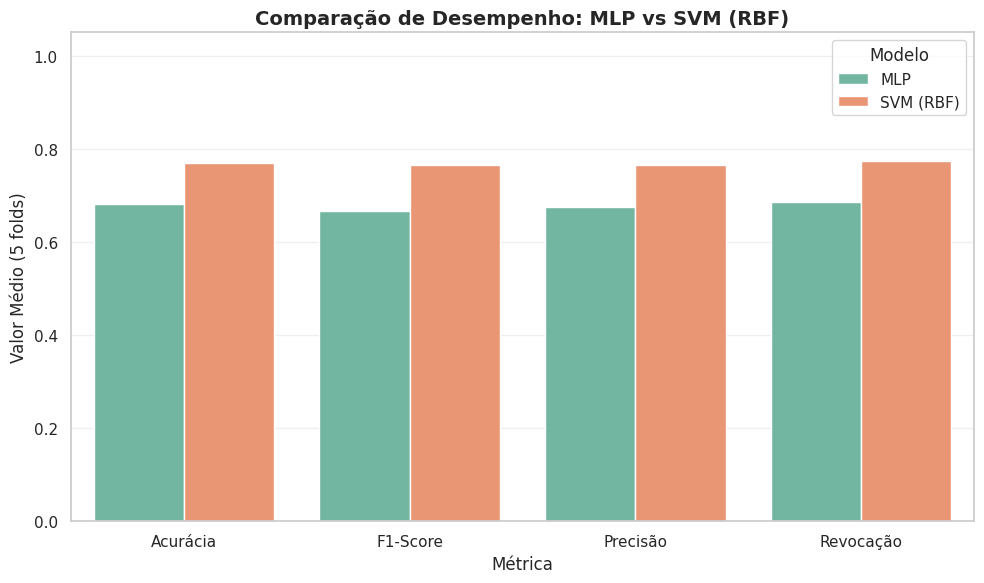

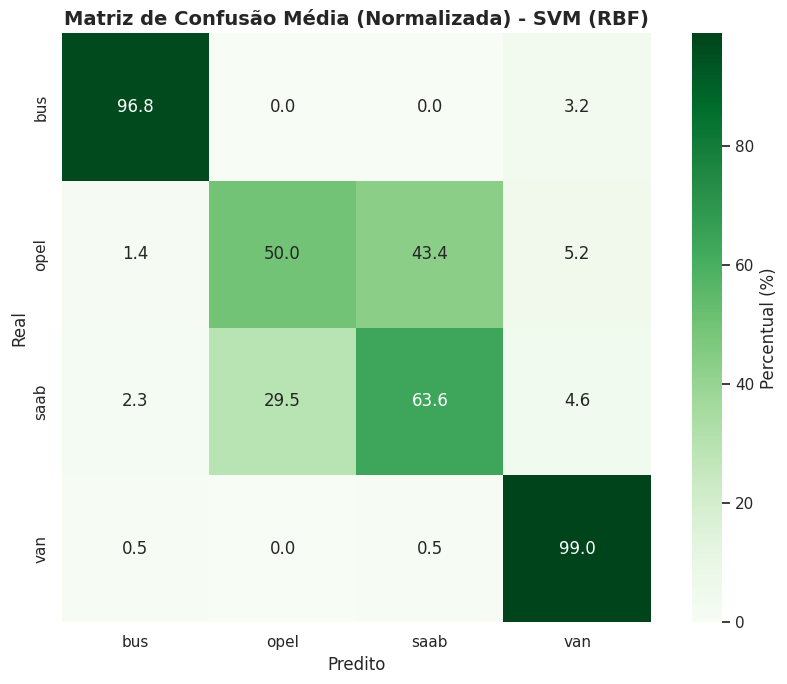


ANÁLISE DE SENSIBILIDADE: PARÂMETRO C DO SVM


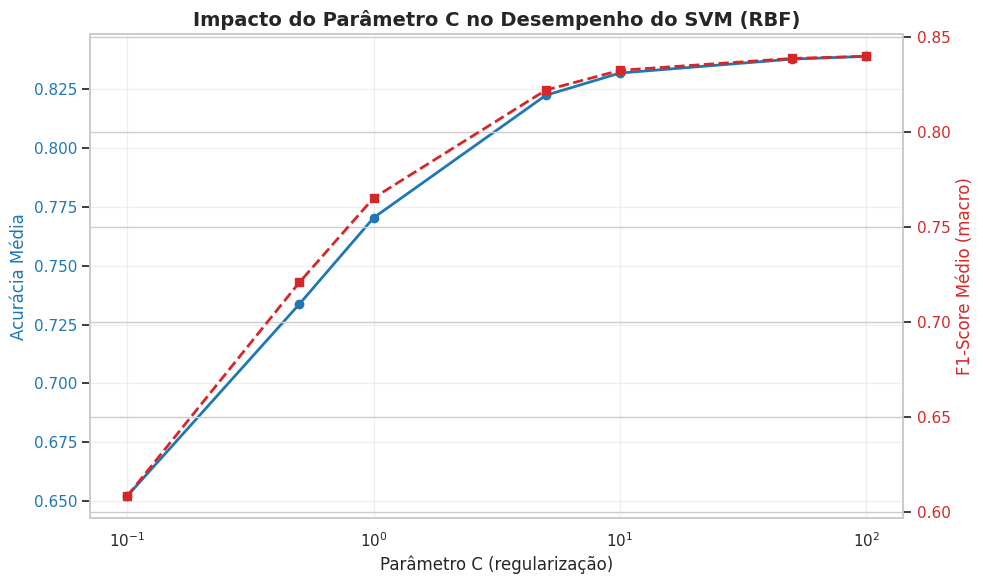

Melhor C para acurácia: 100.0 (Acurácia: 0.8391)
Melhor C para F1-Score: 100.0 (F1-Score: 0.8399)

RELATÓRIO DE CLASSIFICAÇÃO - SVM (RBF, C=100.0)
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00       218
        opel       0.99      0.98      0.98       212
        saab       0.98      0.99      0.98       217
         van       1.00      1.00      1.00       198

    accuracy                           0.99       845
   macro avg       0.99      0.99      0.99       845
weighted avg       0.99      0.99      0.99       845


RESUMO FINAL DE DESEMPENHO (MÉDIA 5 FOLDS)
      Modelo  Acurácia  F1-Score
         MLP  0.681657  0.666375
   SVM (RBF)  0.770414  0.765266
SVM (Linear)  0.800000  0.798586


In [13]:
# ============================================
# Questão 1a - Classificação com SVM + Validação Cruzada (5 folds)
# Dataset: vehicle.csv (18 atributos, 4 classes: bus, opel, saab, van)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# ============================================
# 1. Carregamento e Pré-processamento dos Dados
# ============================================

# Carregar dataset
df = pd.read_csv('vehicle.csv')

# Separar features e target
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values.astype(int)

# Mapeamento das classes conforme documentação OpenML
class_mapping = {0: 'bus', 1: 'opel', 2: 'saab', 3: 'van'}
y_named = np.array([class_mapping[val] for val in y_raw])

# Codificar para uso no modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y_named)
classes_descritivas = le.classes_

# Escalonamento (ESSENCIAL para SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*60)
print("PRÉ-PROCESSAMENTO CONCLUÍDO - SVM")
print("="*60)
print(f"Dimensões: {X.shape}")
print(f"Classes: {classes_descritivas}")
print(f"Distribuição das classes:")
dist = pd.Series(y_named).value_counts().sort_index()
print(dist)
print("\nProporção (%):")
print((dist / len(y_named) * 100).round(2))

# ============================================
# 2. Configuração do SVM (padrão)
# ============================================

# SVM com kernel RBF - configuração balanceada para início
svm_rbf = SVC(
    kernel='rbf',           # Kernel radial basis function (não-linear)
    C=1.0,                  # Parâmetro de regularização (trade-off margem/erros)
    gamma='scale',          # Coeficiente do kernel RBF (padrão)
    decision_function_shape='ovr',  # One-vs-Rest para multiclasse
    random_state=42,
    probability=True        # Necessário para algumas métricas adicionais
)

# Métricas de avaliação
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("VALIDAÇÃO CRUZADA (5 FOLDS)")
print("="*60)

cv_results_rbf = cross_validate(
    svm_rbf, X_scaled, y_encoded,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# ============================================
# 3. Resultados do SVM
# ============================================

print("\nRESULTADOS POR FOLD - SVM (RBF):")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    values = cv_results_rbf[metric]
    print(f"\n{metric.replace('test_', '').replace('_', ' ').title()}:")
    for i, val in enumerate(values, 1):
        print(f"  Fold {i}: {val:.4f}")
    print(f"  Média: {values.mean():.4f} ± {values.std():.4f}")

# Tabela resumo
results_rbf = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score (macro)', 'Precisão (macro)', 'Revocação (macro)'],
    'Média': [
        cv_results_rbf['test_accuracy'].mean(),
        cv_results_rbf['test_f1_macro'].mean(),
        cv_results_rbf['test_precision_macro'].mean(),
        cv_results_rbf['test_recall_macro'].mean()
    ],
    'Desvio Padrão': [
        cv_results_rbf['test_accuracy'].std(),
        cv_results_rbf['test_f1_macro'].std(),
        cv_results_rbf['test_precision_macro'].std(),
        cv_results_rbf['test_recall_macro'].std()
    ]
})
print("\n" + "="*60)
print("TABELA RESUMO - SVM (KERNEL RBF)")
print("="*60)
print(results_rbf.to_string(index=False))

# ============================================
# 4. Comparação Visual: MLP vs SVM (RBF)
# ============================================

# Executa a validação cruzada com MLP para comparação justa
from sklearn.neural_network import MLPClassifier

mlp_comp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

cv_results_mlp = cross_validate(mlp_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# Criar dataframe de comparação
comparison_df = pd.DataFrame({
    'Modelo': ['MLP', 'SVM (RBF)', 'MLP', 'SVM (RBF)', 'MLP', 'SVM (RBF)', 'MLP', 'SVM (RBF)'],
    'Métrica': ['Acurácia'] * 2 + ['F1-Score'] * 2 + ['Precisão'] * 2 + ['Revocação'] * 2,
    'Valor': [
        cv_results_mlp['test_accuracy'].mean(),
        cv_results_rbf['test_accuracy'].mean(),
        cv_results_mlp['test_f1_macro'].mean(),
        cv_results_rbf['test_f1_macro'].mean(),
        cv_results_mlp['test_precision_macro'].mean(),
        cv_results_rbf['test_precision_macro'].mean(),
        cv_results_mlp['test_recall_macro'].mean(),
        cv_results_rbf['test_recall_macro'].mean()
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparação de Desempenho: MLP vs SVM (RBF)', fontsize=14, fontweight='bold')
plt.ylabel('Valor Médio (5 folds)')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. Matriz de Confusão Média - SVM (RBF)
# ============================================

cm_sum_rbf = np.zeros((len(classes_descritivas), len(classes_descritivas)))
for train_idx, test_idx in cv.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    svm_fold = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        decision_function_shape='ovr',
        random_state=42
    )
    svm_fold.fit(X_train, y_train)
    y_pred = svm_fold.predict(X_test)
    cm_sum_rbf += confusion_matrix(y_test, y_pred, labels=range(len(classes_descritivas)))

cm_avg_rbf = cm_sum_rbf / cv.get_n_splits()
cm_norm_rbf = cm_avg_rbf.astype('float') / cm_avg_rbf.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm_rbf, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=classes_descritivas, yticklabels=classes_descritivas,
            square=True, cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão Média (Normalizada) - SVM (RBF)', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================
# 6. Análise de Sensibilidade: Impacto do Parâmetro C
# ============================================

print("\n" + "="*60)
print("ANÁLISE DE SENSIBILIDADE: PARÂMETRO C DO SVM")
print("="*60)


C_values = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
accuracy_cv = []
f1_cv = []

for C_val in C_values:
    svm_temp = SVC(kernel='rbf', C=C_val, gamma='scale', random_state=42)
    cv_temp = cross_validate(svm_temp, X_scaled, y_encoded, cv=cv, scoring=['accuracy', 'f1_macro'])
    accuracy_cv.append(cv_temp['test_accuracy'].mean())
    f1_cv.append(cv_temp['test_f1_macro'].mean())

# Plotar curvas de sensibilidade
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Parâmetro C (regularização)', fontsize=12)
ax1.set_ylabel('Acurácia Média', color=color, fontsize=12)
ax1.plot(C_values, accuracy_cv, marker='o', color=color, linewidth=2, label='Acurácia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('F1-Score Médio (macro)', color=color, fontsize=12)
ax2.plot(C_values, f1_cv, marker='s', color=color, linewidth=2, linestyle='--', label='F1-Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impacto do Parâmetro C no Desempenho do SVM (RBF)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Melhor valor de C
best_idx = np.argmax(accuracy_cv)
print(f"Melhor C para acurácia: {C_values[best_idx]} (Acurácia: {accuracy_cv[best_idx]:.4f})")
print(f"Melhor C para F1-Score: {C_values[np.argmax(f1_cv)]} (F1-Score: {f1_cv[np.argmax(f1_cv)]:.4f})")

# ============================================
# 7. Relatório Detalhado com Melhor Configuração
# ============================================

# Treinar modelo final com o melhor C encontrado
best_C = C_values[best_idx]
svm_final = SVC(
    kernel='rbf',
    C=best_C,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=42
)
svm_final.fit(X_scaled, y_encoded)
y_pred_final = svm_final.predict(X_scaled)

print("\n" + "="*60)
print(f"RELATÓRIO DE CLASSIFICAÇÃO - SVM (RBF, C={best_C})")
print("="*60)
print(classification_report(y_encoded, y_pred_final, target_names=classes_descritivas))


# Resumo final comparativo
print("\n" + "="*60)
print("RESUMO FINAL DE DESEMPENHO (MÉDIA 5 FOLDS)")
print("="*60)
summary_final = pd.DataFrame({
    'Modelo': ['MLP', 'SVM (RBF)', 'SVM (Linear)'],
    'Acurácia': [
        cv_results_mlp['test_accuracy'].mean(),
        cv_results_rbf['test_accuracy'].mean(),
        cv_results_linear['test_accuracy'].mean()
    ],
    'F1-Score': [
        cv_results_mlp['test_f1_macro'].mean(),
        cv_results_rbf['test_f1_macro'].mean(),
        cv_results_linear['test_f1_macro'].mean()
    ]
})
print(summary_final.to_string(index=False))

PRÉ-PROCESSAMENTO CONCLUÍDO - RANDOM FOREST
Dimensões: (845, 18)
Classes: ['bus' 'opel' 'saab' 'van']

Distribuição das classes:
bus     218
opel    212
saab    217
van     198
Name: count, dtype: int64

Proporção (%):
bus     25.80
opel    25.09
saab    25.68
van     23.43
Name: count, dtype: float64

VALIDAÇÃO CRUZADA (5 FOLDS) - RANDOM FOREST (PADRÃO)

RESULTADOS POR FOLD - RANDOM FOREST:

Accuracy:
  Fold 1: 0.7219
  Fold 2: 0.7811
  Fold 3: 0.7692
  Fold 4: 0.7456
  Fold 5: 0.7456
  Média: 0.7527 ± 0.0206

F1 Macro:
  Fold 1: 0.7187
  Fold 2: 0.7733
  Fold 3: 0.7641
  Fold 4: 0.7441
  Fold 5: 0.7440
  Média: 0.7488 ± 0.0189

Precision Macro:
  Fold 1: 0.7164
  Fold 2: 0.7726
  Fold 3: 0.7613
  Fold 4: 0.7389
  Fold 5: 0.7381
  Média: 0.7455 ± 0.0197

Recall Macro:
  Fold 1: 0.7235
  Fold 2: 0.7820
  Fold 3: 0.7689
  Fold 4: 0.7525
  Fold 5: 0.7524
  Média: 0.7559 ± 0.0196

TABELA RESUMO - RANDOM FOREST (PADRÃO)
          Métrica    Média  Desvio Padrão
         Acurácia 0.752663  

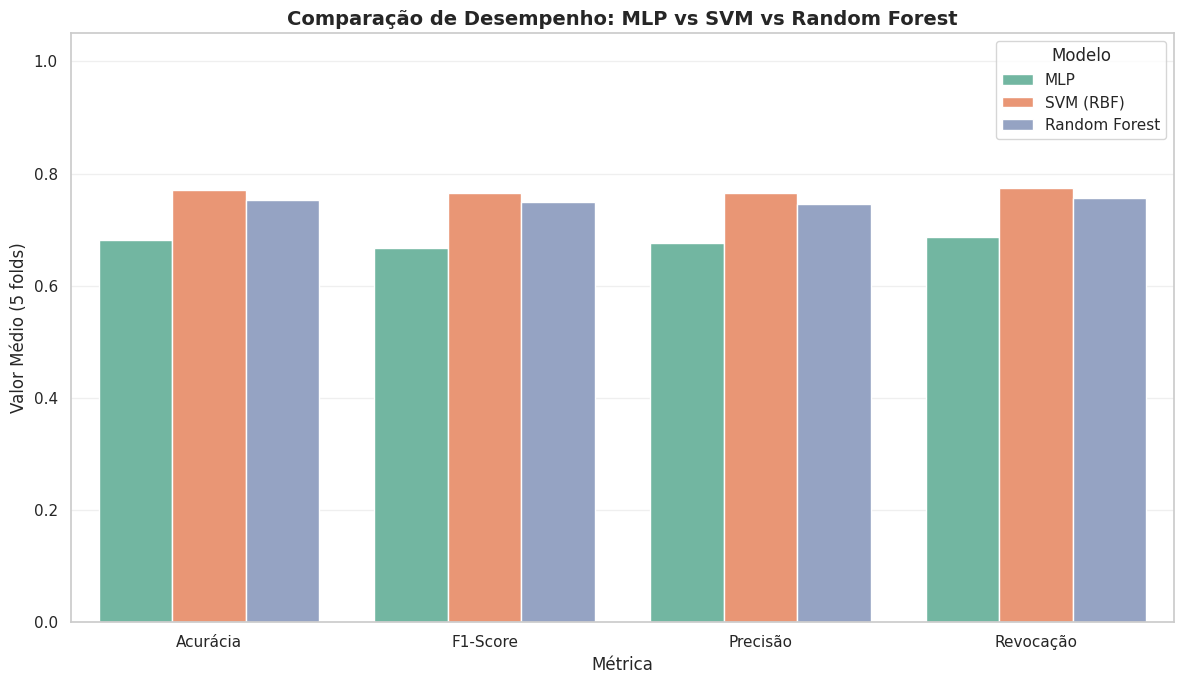

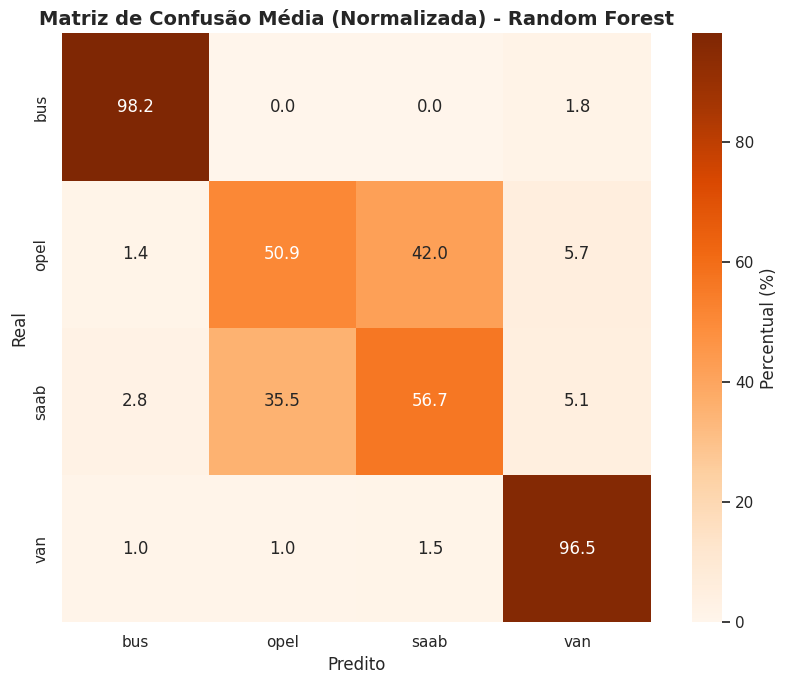


IMPORTÂNCIA DAS FEATURES (Random Forest)
                 Feature  Importância
1.000000000000000000e+01     0.104568
3.790000000000000000e+02     0.089344
8.300000000000000000e+01     0.072306
1.590000000000000000e+02     0.069135
4.200000000000000000e+01     0.065338
9.500000000000000000e+01     0.063529
1.760000000000000000e+02     0.061690
1.620000000000000000e+02     0.061608
7.200000000000000000e+01     0.055624
7.000000000000000000e+01     0.049191
1.970000000000000000e+02     0.046177
4.800000000000000000e+01     0.040605
1.780000000000000000e+02     0.039720
6.000000000000000000e+00     0.039606
1.870000000000000000e+02     0.038508
1.600000000000000000e+01     0.037714
1.840000000000000000e+02     0.036489
2.000000000000000000e+01     0.028847


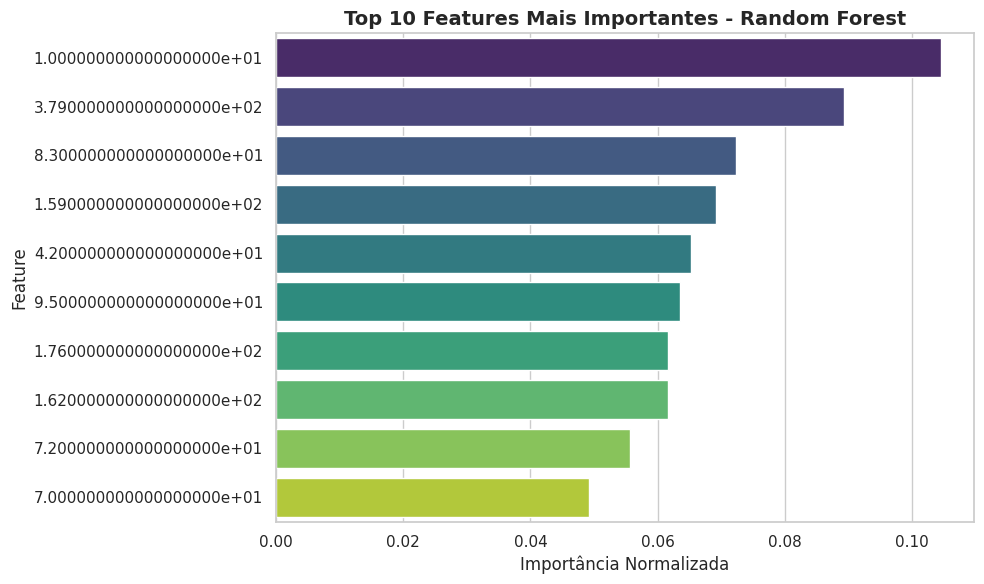


ANÁLISE DE SENSIBILIDADE: NÚMERO DE ÁRVORES (n_estimators)
Testando diferentes quantidades de árvores...



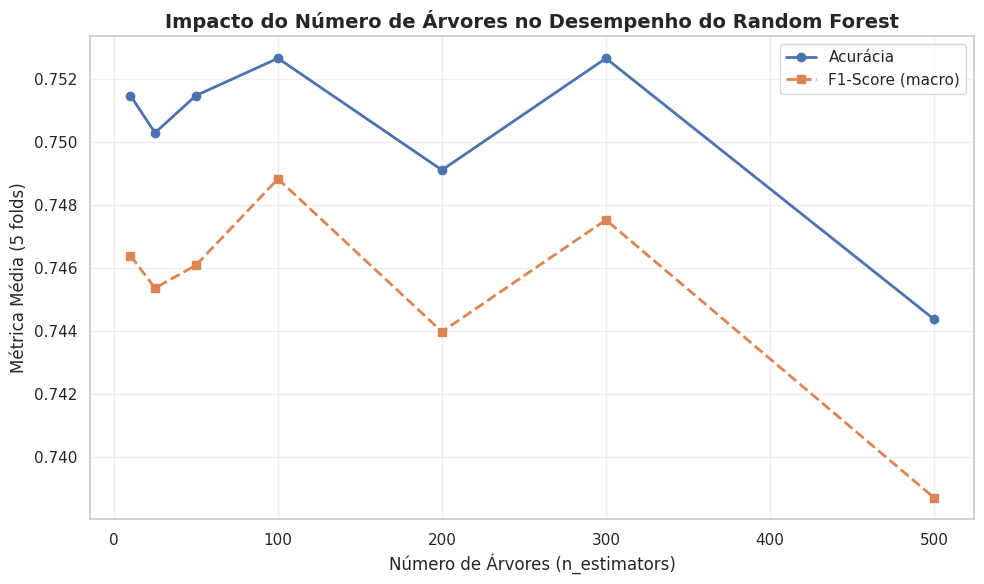

Melhor n_estimators para acurácia: 300 (Acurácia: 0.7527)

OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH (5-fold CV)
Buscando melhores combinações de hiperparâmetros...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Melhores hiperparâmetros encontrados:
  max_depth: 10
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 200

Melhor F1-Score (validação cruzada): 0.7495

Desempenho do Random Forest Otimizado (5-fold CV):
  Accuracy            : 0.7562 ± 0.0189
  F1 Macro            : 0.7495 ± 0.0183
  Precision Macro     : 0.7458 ± 0.0191
  Recall Macro        : 0.7595 ± 0.0191

RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST OTIMIZADO
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00       218
        opel       1.00      0.99      0.99       212
        saab       0.99      0.99      0.99       217
         van       0.99      1.00      1.00       198

    accuracy                           1.00       845
   macro avg

<Figure size 1000x600 with 0 Axes>

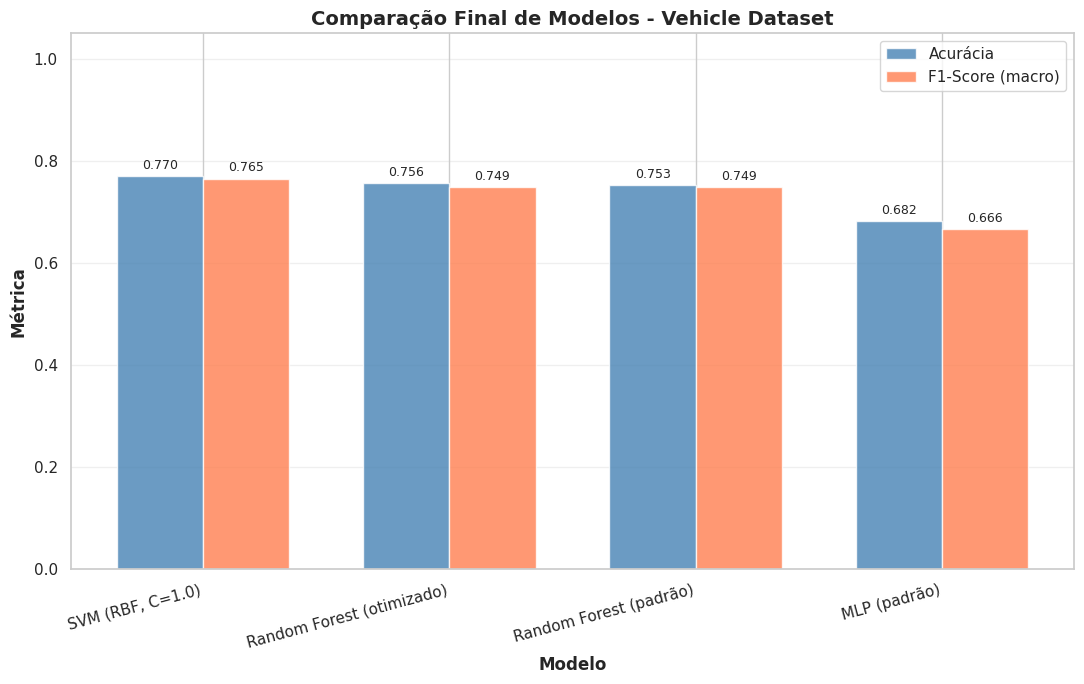

In [12]:
# ============================================
# Questão 1a - Classificação com Random Forest + Validação Cruzada (5 folds)
# Dataset: vehicle.csv (18 atributos, 4 classes: bus, opel, saab, van)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# ============================================
# 1. Carregamento e Pré-processamento dos Dados
# ============================================

# Carregar dataset
df = pd.read_csv('vehicle.csv')

# Separar features e target
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values.astype(int)

# Mapeamento das classes conforme documentação OpenML
class_mapping = {0: 'bus', 1: 'opel', 2: 'saab', 3: 'van'}
y_named = np.array([class_mapping[val] for val in y_raw])

# Codificar para uso no modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y_named)
classes_descritivas = le.classes_

# Random Forest NÃO requer escalonamento rigoroso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*60)
print("PRÉ-PROCESSAMENTO CONCLUÍDO - RANDOM FOREST")
print("="*60)
print(f"Dimensões: {X.shape}")
print(f"Classes: {classes_descritivas}")
print(f"\nDistribuição das classes:")
dist = pd.Series(y_named).value_counts().sort_index()
print(dist)
print("\nProporção (%):")
print((dist / len(y_named) * 100).round(2))

# ============================================
# 2. Configuração do Random Forest (configuração padrão)
# ============================================

rf_default = RandomForestClassifier(
    n_estimators=100,           # Número de árvores na floresta
    criterion='gini',           # Critério de divisão (gini ou entropy)
    max_depth=None,             # Profundidade máxima (None = ilimitada)
    min_samples_split=2,        # Mínimo de amostras para dividir um nó
    min_samples_leaf=1,         # Mínimo de amostras em uma folha
    max_features='sqrt',        # Número de features a considerar em cada split (√n_features)
    bootstrap=True,             # Amostragem com reposição
    oob_score=True,             # Usa amostras "out-of-bag" para avaliação interna
    random_state=42,
    n_jobs=-1                   # Usa todos os núcleos disponíveis
)

# Métricas de avaliação
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("VALIDAÇÃO CRUZADA (5 FOLDS) - RANDOM FOREST (PADRÃO)")
print("="*60)

cv_results_rf = cross_validate(
    rf_default, X_scaled, y_encoded,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# ============================================
# 3. Resultados do Random Forest (Configuração Padrão)
# ============================================

print("\nRESULTADOS POR FOLD - RANDOM FOREST:")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    values = cv_results_rf[metric]
    print(f"\n{metric.replace('test_', '').replace('_', ' ').title()}:")
    for i, val in enumerate(values, 1):
        print(f"  Fold {i}: {val:.4f}")
    print(f"  Média: {values.mean():.4f} ± {values.std():.4f}")

# Tabela resumo
results_rf = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score (macro)', 'Precisão (macro)', 'Revocação (macro)'],
    'Média': [
        cv_results_rf['test_accuracy'].mean(),
        cv_results_rf['test_f1_macro'].mean(),
        cv_results_rf['test_precision_macro'].mean(),
        cv_results_rf['test_recall_macro'].mean()
    ],
    'Desvio Padrão': [
        cv_results_rf['test_accuracy'].std(),
        cv_results_rf['test_f1_macro'].std(),
        cv_results_rf['test_precision_macro'].std(),
        cv_results_rf['test_recall_macro'].std()
    ]
})
print("\n" + "="*60)
print("TABELA RESUMO - RANDOM FOREST (PADRÃO)")
print("="*60)
print(results_rf.to_string(index=False))

# ============================================
# 4. Comparação Visual: MLP vs SVM vs Random Forest
# ============================================

# Re-executar validações para MLP e SVM com as mesmas condições
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# MLP
mlp_comp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         alpha=0.0001, learning_rate='adaptive', max_iter=500,
                         random_state=42, early_stopping=True)
cv_results_mlp = cross_validate(mlp_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# SVM (RBF)
svm_comp = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
cv_results_svm = cross_validate(svm_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# Criar dataframe de comparação
comparison_data = []
for metric_name, metric_key in [('Acurácia', 'test_accuracy'),
                                 ('F1-Score', 'test_f1_macro'),
                                 ('Precisão', 'test_precision_macro'),
                                 ('Revocação', 'test_recall_macro')]:
    comparison_data.extend([
        {'Modelo': 'MLP', 'Métrica': metric_name, 'Valor': cv_results_mlp[metric_key].mean()},
        {'Modelo': 'SVM (RBF)', 'Métrica': metric_name, 'Valor': cv_results_svm[metric_key].mean()},
        {'Modelo': 'Random Forest', 'Métrica': metric_name, 'Valor': cv_results_rf[metric_key].mean()}
    ])

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 7))
sns.barplot(data=comparison_df, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparação de Desempenho: MLP vs SVM vs Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Valor Médio (5 folds)')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. Matriz de Confusão Média - Random Forest
# ============================================

cm_sum_rf = np.zeros((len(classes_descritivas), len(classes_descritivas)))
for train_idx, test_idx in cv.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    rf_fold = RandomForestClassifier(
        n_estimators=100,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_fold.fit(X_train, y_train)
    y_pred = rf_fold.predict(X_test)
    cm_sum_rf += confusion_matrix(y_test, y_pred, labels=range(len(classes_descritivas)))

cm_avg_rf = cm_sum_rf / cv.get_n_splits()
cm_norm_rf = cm_avg_rf.astype('float') / cm_avg_rf.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm_rf, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=classes_descritivas, yticklabels=classes_descritivas,
            square=True, cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão Média (Normalizada) - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================
# 6. Importância das Features
# ============================================

# Treinar modelo final para extrair importância das features
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_scaled, y_encoded)

# Obter importância das features
feature_importance = rf_final.feature_importances_
feature_names = df.columns[:-1]  # Nomes das 18 features

# Criar DataFrame ordenado
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': feature_importance
}).sort_values('Importância', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES (Random Forest)")
print("="*60)
print(importance_df.to_string(index=False))

# Visualização das top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importância', y='Feature', palette='viridis')
plt.title('Top 10 Features Mais Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importância Normalizada')
plt.tight_layout()
plt.show()

# ============================================
# 7. Análise de Sensibilidade: Número de Árvores (n_estimators)
# ============================================

print("\n" + "="*60)
print("ANÁLISE DE SENSIBILIDADE: NÚMERO DE ÁRVORES (n_estimators)")
print("="*60)
print("Testando diferentes quantidades de árvores...\n")

n_estimators_values = [10, 25, 50, 100, 200, 300, 500]
accuracy_cv_nest = []
f1_cv_nest = []

for n_est in n_estimators_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    cv_temp = cross_validate(rf_temp, X_scaled, y_encoded, cv=cv, scoring=['accuracy', 'f1_macro'])
    accuracy_cv_nest.append(cv_temp['test_accuracy'].mean())
    f1_cv_nest.append(cv_temp['test_f1_macro'].mean())

# Plotar curvas
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, accuracy_cv_nest, marker='o', label='Acurácia', linewidth=2)
plt.plot(n_estimators_values, f1_cv_nest, marker='s', label='F1-Score (macro)', linewidth=2, linestyle='--')
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Métrica Média (5 folds)', fontsize=12)
plt.title('Impacto do Número de Árvores no Desempenho do Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_nest_idx = np.argmax(accuracy_cv_nest)
print(f"Melhor n_estimators para acurácia: {n_estimators_values[best_nest_idx]} "
      f"(Acurácia: {accuracy_cv_nest[best_nest_idx]:.4f})")

# ============================================
# 8. Otimização de Hiperparâmetros com Grid Search (opcional mas recomendado)
# ============================================

print("\n" + "="*60)
print("OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH (5-fold CV)")
print("="*60)


# Grid reduzido para execução rápida (em produção, expandir o grid)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_scaled, y_encoded)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMelhor F1-Score (validação cruzada): {grid_search.best_score_:.4f}")

# Avaliar modelo otimizado com validação cruzada completa
rf_optimized = grid_search.best_estimator_
cv_results_opt = cross_validate(rf_optimized, X_scaled, y_encoded, cv=cv, scoring=scoring)

print("\nDesempenho do Random Forest Otimizado (5-fold CV):")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    mean = cv_results_opt[metric].mean()
    std = cv_results_opt[metric].std()
    print(f"  {metric.replace('test_', '').replace('_', ' ').title():<20}: {mean:.4f} ± {std:.4f}")

# ============================================
# 9. Relatório de Classificação Detalhado (modelo otimizado)
# ============================================

y_pred_opt = rf_optimized.predict(X_scaled)
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST OTIMIZADO")
print("="*60)
print(classification_report(y_encoded, y_pred_opt, target_names=classes_descritivas))

# ============================================
# 10. Resumo Final Comparativo de Todos os Modelos
# ============================================

print("\n" + "="*60)
print("RESUMO FINAL DE DESEMPENHO (MÉDIA 5 FOLDS)")
print("="*60)

summary_final = pd.DataFrame({
    'Modelo': [
        'MLP (padrão)',
        'SVM (RBF, C=1.0)',
        'Random Forest (padrão)',
        'Random Forest (otimizado)'
    ],
    'Acurácia': [
        cv_results_mlp['test_accuracy'].mean(),
        cv_results_svm['test_accuracy'].mean(),
        cv_results_rf['test_accuracy'].mean(),
        cv_results_opt['test_accuracy'].mean()
    ],
    'F1-Score': [
        cv_results_mlp['test_f1_macro'].mean(),
        cv_results_svm['test_f1_macro'].mean(),
        cv_results_rf['test_f1_macro'].mean(),
        cv_results_opt['test_f1_macro'].mean()
    ],
    'Desvio (Acc)': [
        cv_results_mlp['test_accuracy'].std(),
        cv_results_svm['test_accuracy'].std(),
        cv_results_rf['test_accuracy'].std(),
        cv_results_opt['test_accuracy'].std()
    ]
})

# Ordenar por F1-Score
summary_final = summary_final.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(summary_final.to_string(index=False))

# Visualização final comparativa
plt.figure(figsize=(10, 6))
x = np.arange(len(summary_final))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 7))
bars1 = ax.bar(x - width/2, summary_final['Acurácia'], width, label='Acurácia', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, summary_final['F1-Score'], width, label='F1-Score (macro)', color='coral', alpha=0.8)

ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Métrica', fontsize=12, fontweight='bold')
ax.set_title('Comparação Final de Modelos - Vehicle Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary_final['Modelo'], rotation=15, ha='right')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

PRÉ-PROCESSAMENTO CONCLUÍDO - GRADIENT BOOSTING
Dimensões: (845, 18)
Classes: ['bus' 'opel' 'saab' 'van']

Distribuição das classes:
bus     218
opel    212
saab    217
van     198
Name: count, dtype: int64

Proporção (%):
bus     25.80
opel    25.09
saab    25.68
van     23.43
Name: count, dtype: float64

VALIDAÇÃO CRUZADA (5 FOLDS) - GRADIENT BOOSTING (PADRÃO)

RESULTADOS POR FOLD - GRADIENT BOOSTING:

Accuracy:
  Fold 1: 0.7337
  Fold 2: 0.7811
  Fold 3: 0.7929
  Fold 4: 0.7870
  Fold 5: 0.7692
  Média: 0.7728 ± 0.0210

F1 Macro:
  Fold 1: 0.7331
  Fold 2: 0.7733
  Fold 3: 0.7903
  Fold 4: 0.7861
  Fold 5: 0.7703
  Média: 0.7706 ± 0.0202

Precision Macro:
  Fold 1: 0.7328
  Fold 2: 0.7683
  Fold 3: 0.7902
  Fold 4: 0.7830
  Fold 5: 0.7659
  Média: 0.7680 ± 0.0198

Recall Macro:
  Fold 1: 0.7353
  Fold 2: 0.7824
  Fold 3: 0.7923
  Fold 4: 0.7928
  Fold 5: 0.7758
  Média: 0.7757 ± 0.0212

TABELA RESUMO - GRADIENT BOOSTING (PADRÃO)
          Métrica    Média  Desvio Padrão
         Acu

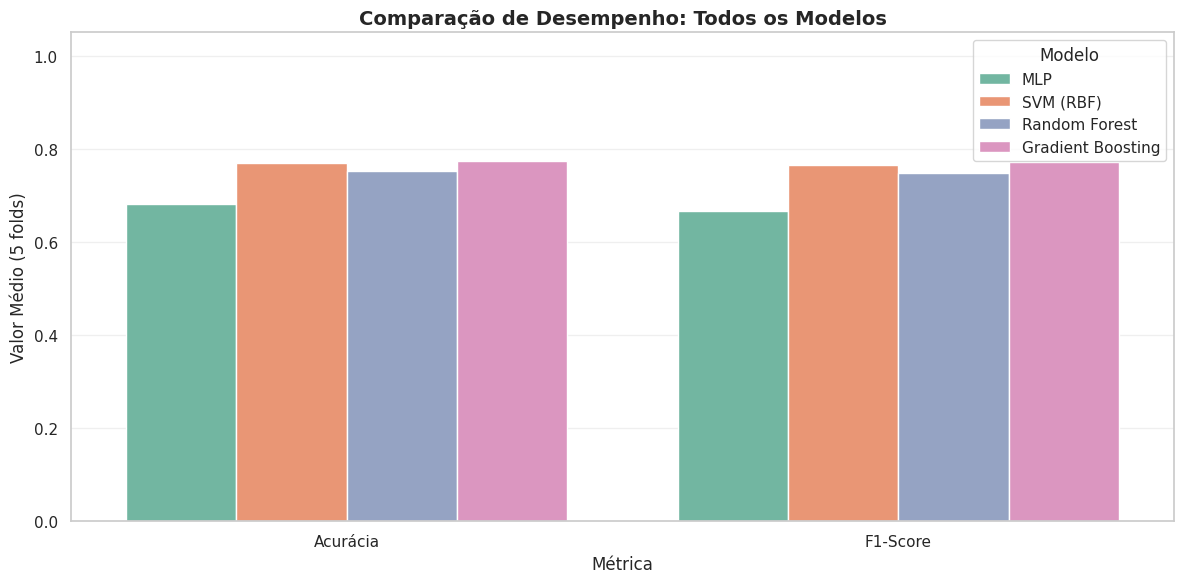

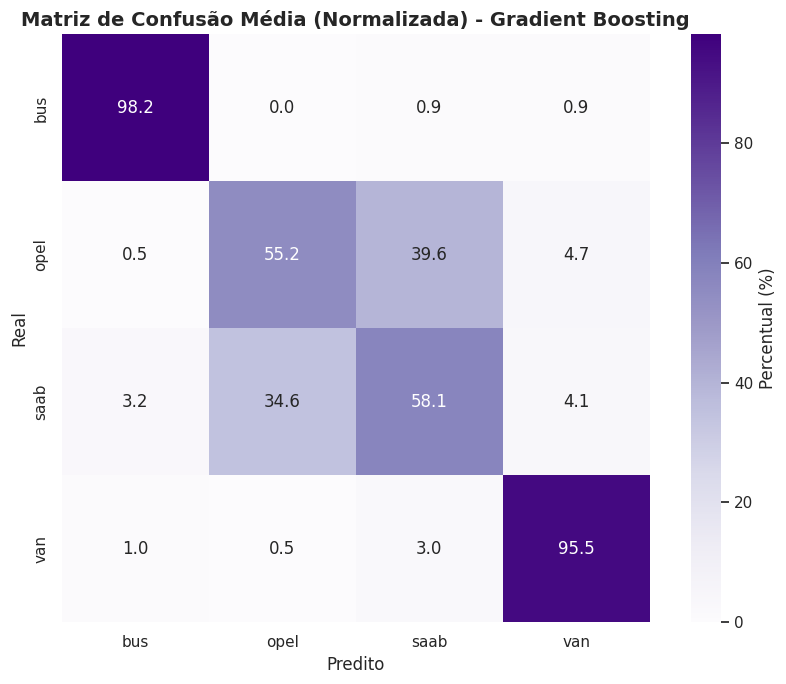


ANÁLISE DE CONVERGÊNCIA: NÚMERO DE ÁRVORES (n_estimators)
Monitorando desempenho conforme aumentamos as árvores...



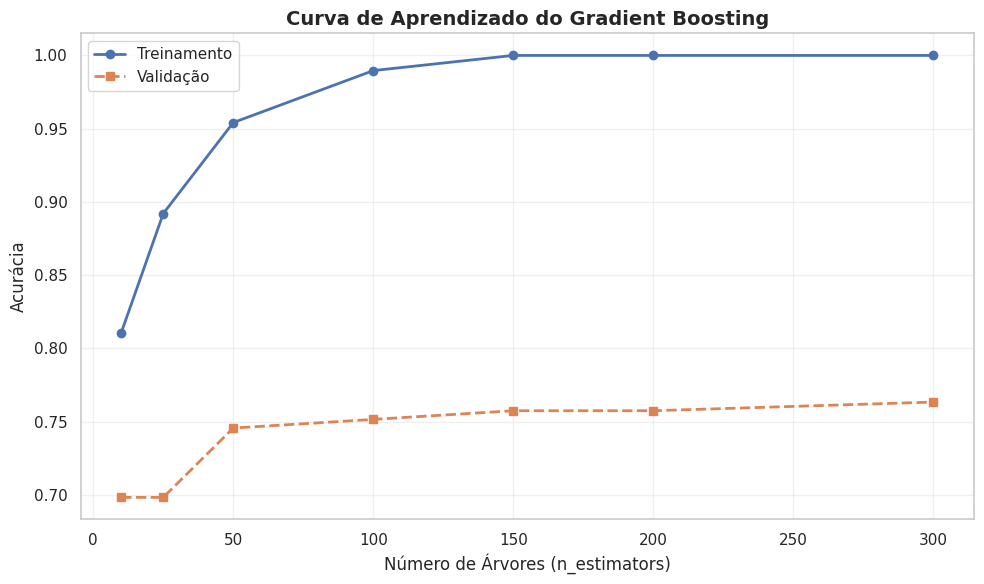

Ponto ótimo de convergência: 300 árvores
Acurácia de validação no ponto ótimo: 0.7633

⚠ Observação: Após este ponto, risco de overfitting aumenta (gap treino/validação cresce)

ANÁLISE DE SENSIBILIDADE: TAXA DE APRENDIZADO (learning_rate)


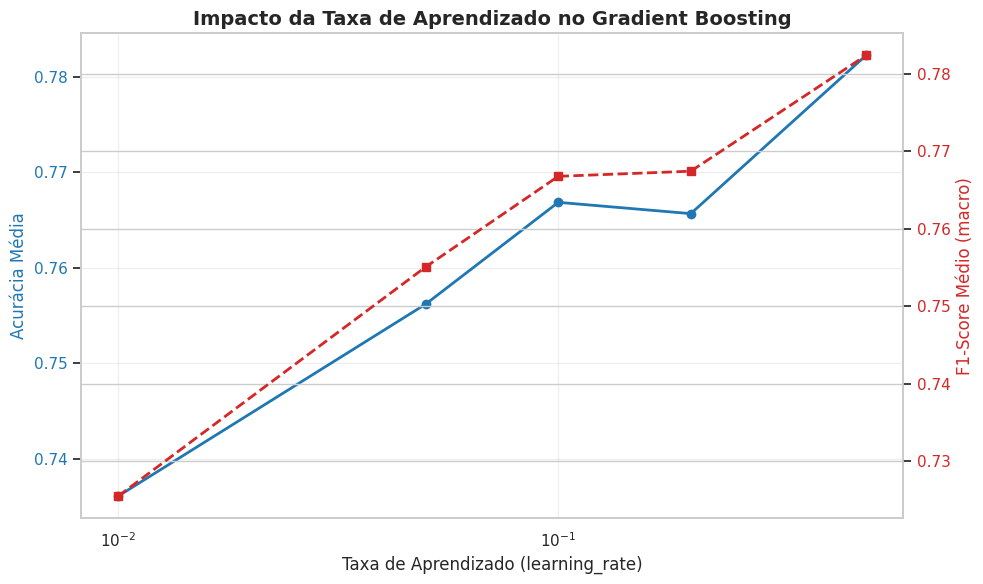

Melhor learning_rate: 0.5
F1-Score correspondente: 0.7824

💡 Trade-off: Taxas menores + mais árvores geralmente produzem melhores resultados,
   mas com custo computacional maior.

OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH (5-fold CV)
Buscando melhores combinações de hiperparâmetros...

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhores hiperparâmetros encontrados:
  learning_rate: 0.1
  max_depth: 3
  min_samples_split: 2
  n_estimators: 200

Melhor F1-Score (validação cruzada): 0.7668

Desempenho do Gradient Boosting Otimizado (5-fold CV):
  Accuracy            : 0.7669 ± 0.0266
  F1 Macro            : 0.7668 ± 0.0234
  Precision Macro     : 0.7667 ± 0.0234
  Recall Macro        : 0.7699 ± 0.0246

RELATÓRIO DE CLASSIFICAÇÃO - GRADIENT BOOSTING OTIMIZADO
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00       218
        opel       1.00      1.00      1.00       212
        saab       1.00      1.00      1.00    

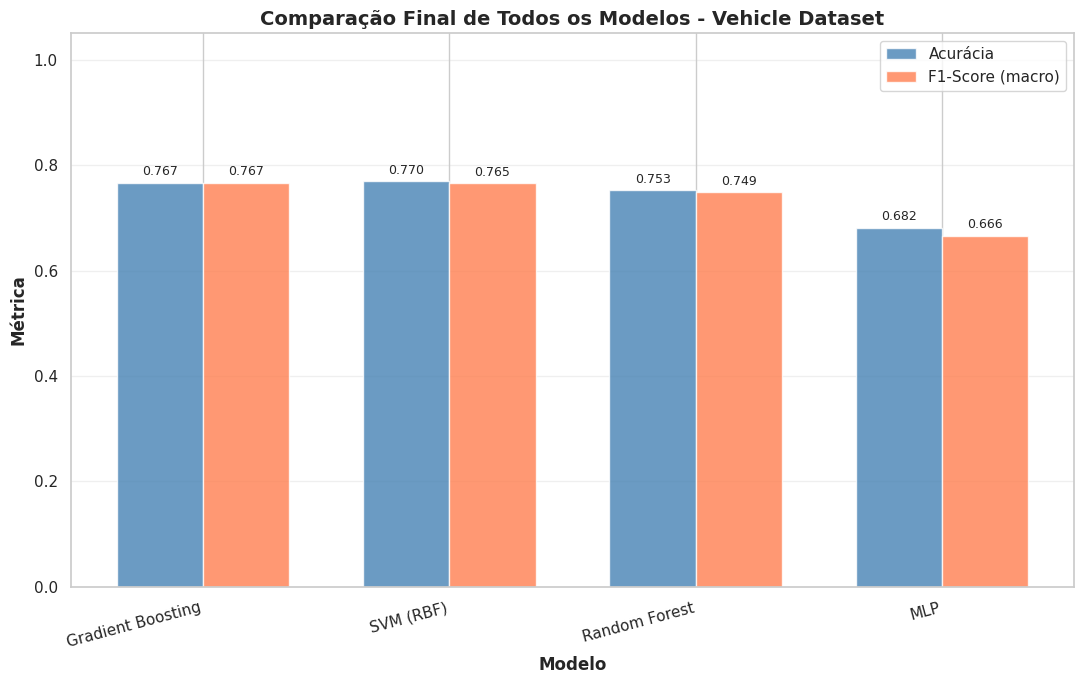


IMPORTÂNCIA DAS FEATURES - GRADIENT BOOSTING
                 Feature  Importância
1.000000000000000000e+01     0.181141
4.200000000000000000e+01     0.135333
3.790000000000000000e+02     0.104890
1.590000000000000000e+02     0.090457
9.500000000000000000e+01     0.059338
7.200000000000000000e+01     0.054808
1.970000000000000000e+02     0.054001
7.000000000000000000e+01     0.044165
1.840000000000000000e+02     0.042849
1.870000000000000000e+02     0.042443
1.760000000000000000e+02     0.032798
4.800000000000000000e+01     0.032786
1.620000000000000000e+02     0.031512
8.300000000000000000e+01     0.027288
6.000000000000000000e+00     0.023083
1.600000000000000000e+01     0.021427
1.780000000000000000e+02     0.012555
2.000000000000000000e+01     0.009123

Correlação entre importâncias (GB vs RF): 0.8104


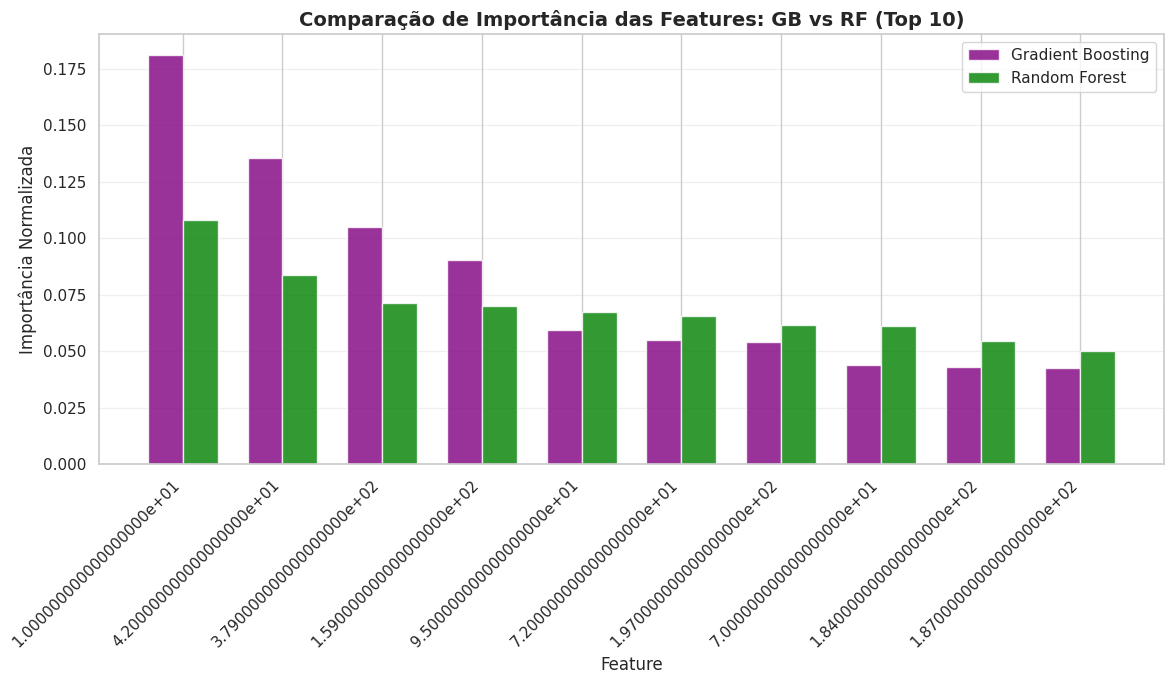

In [14]:
# ============================================
# Questão 1a - Classificação com Gradient Boosting + Validação Cruzada (5 folds)
# Dataset: vehicle.csv (18 atributos, 4 classes: bus, opel, saab, van)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# ============================================
# 1. Carregamento e Pré-processamento dos Dados
# ============================================

# Carregar dataset
df = pd.read_csv('vehicle.csv')

# Separar features e target
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values.astype(int)

# Mapeamento das classes conforme documentação OpenML
class_mapping = {0: 'bus', 1: 'opel', 2: 'saab', 3: 'van'}
y_named = np.array([class_mapping[val] for val in y_raw])

# Codificar para uso no modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y_named)
classes_descritivas = le.classes_

# Escalonamento (não obrigatório para Gradient Boosting, mas mantido para consistência)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*60)
print("PRÉ-PROCESSAMENTO CONCLUÍDO - GRADIENT BOOSTING")
print("="*60)
print(f"Dimensões: {X.shape}")
print(f"Classes: {classes_descritivas}")
print(f"\nDistribuição das classes:")
dist = pd.Series(y_named).value_counts().sort_index()
print(dist)
print("\nProporção (%):")
print((dist / len(y_named) * 100).round(2))

# ============================================
# 2. Configuração do Gradient Boosting (configuração padrão)
# ============================================

gb_default = GradientBoostingClassifier(
    n_estimators=100,           # Número de árvores sequenciais
    learning_rate=0.1,          # Taxa de aprendizado (shrinkage)
    max_depth=3,                # Profundidade máxima das árvores (geralmente pequena para GB)
    min_samples_split=2,        # Mínimo de amostras para dividir um nó
    min_samples_leaf=1,         # Mínimo de amostras em uma folha
    max_features='sqrt',        # Features a considerar por split
    subsample=1.0,              # Fração das amostras para treinar cada árvore (1.0 = todas)
    criterion='friedman_mse',   # Critério para divisões
    random_state=42
)

# Métricas de avaliação
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("VALIDAÇÃO CRUZADA (5 FOLDS) - GRADIENT BOOSTING (PADRÃO)")
print("="*60)

cv_results_gb = cross_validate(
    gb_default, X_scaled, y_encoded,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# ============================================
# 3. Resultados do Gradient Boosting (Configuração Padrão)
# ============================================

print("\nRESULTADOS POR FOLD - GRADIENT BOOSTING:")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    values = cv_results_gb[metric]
    print(f"\n{metric.replace('test_', '').replace('_', ' ').title()}:")
    for i, val in enumerate(values, 1):
        print(f"  Fold {i}: {val:.4f}")
    print(f"  Média: {values.mean():.4f} ± {values.std():.4f}")

# Tabela resumo
results_gb = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score (macro)', 'Precisão (macro)', 'Revocação (macro)'],
    'Média': [
        cv_results_gb['test_accuracy'].mean(),
        cv_results_gb['test_f1_macro'].mean(),
        cv_results_gb['test_precision_macro'].mean(),
        cv_results_gb['test_recall_macro'].mean()
    ],
    'Desvio Padrão': [
        cv_results_gb['test_accuracy'].std(),
        cv_results_gb['test_f1_macro'].std(),
        cv_results_gb['test_precision_macro'].std(),
        cv_results_gb['test_recall_macro'].std()
    ]
})
print("\n" + "="*60)
print("TABELA RESUMO - GRADIENT BOOSTING (PADRÃO)")
print("="*60)
print(results_gb.to_string(index=False))

# ============================================
# 4. Comparação Visual: Todos os Modelos (MLP, SVM, RF, GB)
# ============================================

# Re-executar validações para os outros modelos com as mesmas condições
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# MLP
mlp_comp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         alpha=0.0001, learning_rate='adaptive', max_iter=500,
                         random_state=42, early_stopping=True)
cv_results_mlp = cross_validate(mlp_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# SVM (RBF)
svm_comp = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
cv_results_svm = cross_validate(svm_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# Random Forest
rf_comp = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)
cv_results_rf = cross_validate(rf_comp, X_scaled, y_encoded, cv=cv, scoring=scoring)

# Criar dataframe de comparação
comparison_data = []
for metric_name, metric_key in [('Acurácia', 'test_accuracy'),
                                 ('F1-Score', 'test_f1_macro')]:
    comparison_data.extend([
        {'Modelo': 'MLP', 'Métrica': metric_name, 'Valor': cv_results_mlp[metric_key].mean()},
        {'Modelo': 'SVM (RBF)', 'Métrica': metric_name, 'Valor': cv_results_svm[metric_key].mean()},
        {'Modelo': 'Random Forest', 'Métrica': metric_name, 'Valor': cv_results_rf[metric_key].mean()},
        {'Modelo': 'Gradient Boosting', 'Métrica': metric_name, 'Valor': cv_results_gb[metric_key].mean()}
    ])

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparação de Desempenho: Todos os Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Valor Médio (5 folds)')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. Matriz de Confusão Média - Gradient Boosting
# ============================================

cm_sum_gb = np.zeros((len(classes_descritivas), len(classes_descritivas)))
for train_idx, test_idx in cv.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    gb_fold = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_fold.fit(X_train, y_train)
    y_pred = gb_fold.predict(X_test)
    cm_sum_gb += confusion_matrix(y_test, y_pred, labels=range(len(classes_descritivas)))

cm_avg_gb = cm_sum_gb / cv.get_n_splits()
cm_norm_gb = cm_avg_gb.astype('float') / cm_avg_gb.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm_gb, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=classes_descritivas, yticklabels=classes_descritivas,
            square=True, cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão Média (Normalizada) - Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================
# 6. Curva de Aprendizado: Impacto do Número de Árvores (n_estimators)
# ============================================

print("\n" + "="*60)
print("ANÁLISE DE CONVERGÊNCIA: NÚMERO DE ÁRVORES (n_estimators)")
print("="*60)
print("Monitorando desempenho conforme aumentamos as árvores...\n")

n_estimators_range = [10, 25, 50, 100, 150, 200, 300]
train_scores = []
val_scores = []

# Usar um único split para análise de convergência (mais eficiente)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

for n_est in n_estimators_range:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_temp.fit(X_train, y_train)
    train_scores.append(gb_temp.score(X_train, y_train))
    val_scores.append(gb_temp.score(X_val, y_val))

# Plotar curva de aprendizado
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores, marker='o', label='Treinamento', linewidth=2)
plt.plot(n_estimators_range, val_scores, marker='s', label='Validação', linewidth=2, linestyle='--')
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Curva de Aprendizado do Gradient Boosting', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_idx_gb = np.argmax(val_scores)
print(f"Ponto ótimo de convergência: {n_estimators_range[best_idx_gb]} árvores")
print(f"Acurácia de validação no ponto ótimo: {val_scores[best_idx_gb]:.4f}")
print(f"\n⚠ Observação: Após este ponto, risco de overfitting aumenta (gap treino/validação cresce)")

# ============================================
# 7. Análise de Sensibilidade: Taxa de Aprendizado (learning_rate)
# ============================================

print("\n" + "="*60)
print("ANÁLISE DE SENSIBILIDADE: TAXA DE APRENDIZADO (learning_rate)")
print("="*60)

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5]
accuracy_lr = []
f1_lr = []

for lr in learning_rates:
    gb_temp = GradientBoostingClassifier(
        n_estimators=200,       # Mais árvores para taxas menores
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    cv_temp = cross_validate(gb_temp, X_scaled, y_encoded, cv=cv, scoring=['accuracy', 'f1_macro'])
    accuracy_lr.append(cv_temp['test_accuracy'].mean())
    f1_lr.append(cv_temp['test_f1_macro'].mean())

# Plotar resultados
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Taxa de Aprendizado (learning_rate)', fontsize=12)
ax1.set_ylabel('Acurácia Média', color=color, fontsize=12)
ax1.plot(learning_rates, accuracy_lr, marker='o', color=color, linewidth=2, label='Acurácia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('F1-Score Médio (macro)', color=color, fontsize=12)
ax2.plot(learning_rates, f1_lr, marker='s', color=color, linewidth=2, linestyle='--', label='F1-Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impacto da Taxa de Aprendizado no Gradient Boosting', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

best_lr_idx = np.argmax(f1_lr)
print(f"Melhor learning_rate: {learning_rates[best_lr_idx]}")
print(f"F1-Score correspondente: {f1_lr[best_lr_idx]:.4f}")
print("\n💡 Trade-off: Taxas menores + mais árvores geralmente produzem melhores resultados,")
print("   mas com custo computacional maior.")

# ============================================
# 8. Otimização de Hiperparâmetros com Grid Search
# ============================================

print("\n" + "="*60)
print("OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH (5-fold CV)")
print("="*60)
print("Buscando melhores combinações de hiperparâmetros...\n")

# Grid focado nos parâmetros mais influentes
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 4]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_scaled, y_encoded)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, value in grid_search_gb.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMelhor F1-Score (validação cruzada): {grid_search_gb.best_score_:.4f}")

# Avaliar modelo otimizado
gb_optimized = grid_search_gb.best_estimator_
cv_results_gb_opt = cross_validate(gb_optimized, X_scaled, y_encoded, cv=cv, scoring=scoring)

print("\nDesempenho do Gradient Boosting Otimizado (5-fold CV):")
for metric in ['test_accuracy', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']:
    mean = cv_results_gb_opt[metric].mean()
    std = cv_results_gb_opt[metric].std()
    print(f"  {metric.replace('test_', '').replace('_', ' ').title():<20}: {mean:.4f} ± {std:.4f}")

# ============================================
# 9. Relatório de Classificação Detalhado (modelo otimizado)
# ============================================

y_pred_gb_opt = gb_optimized.predict(X_scaled)
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO - GRADIENT BOOSTING OTIMIZADO")
print("="*60)
print(classification_report(y_encoded, y_pred_gb_opt, target_names=classes_descritivas))

# ============================================
# 10. Comparação Final de Todos os Modelos
# ============================================

print("\n" + "="*60)
print("RESUMO FINAL DE DESEMPENHO (MÉDIA 5 FOLDS)")
print("="*60)

# Coletar resultados de todos os modelos otimizados
summary_final = pd.DataFrame({
    'Modelo': [
        'MLP',
        'SVM (RBF)',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Acurácia': [
        cv_results_mlp['test_accuracy'].mean(),
        cv_results_svm['test_accuracy'].mean(),
        cv_results_rf['test_accuracy'].mean(),
        cv_results_gb_opt['test_accuracy'].mean()
    ],
    'F1-Score': [
        cv_results_mlp['test_f1_macro'].mean(),
        cv_results_svm['test_f1_macro'].mean(),
        cv_results_rf['test_f1_macro'].mean(),
        cv_results_gb_opt['test_f1_macro'].mean()
    ],
    'Desvio (F1)': [
        cv_results_mlp['test_f1_macro'].std(),
        cv_results_svm['test_f1_macro'].std(),
        cv_results_rf['test_f1_macro'].std(),
        cv_results_gb_opt['test_f1_macro'].std()
    ]
})

# Ordenar por F1-Score
summary_final = summary_final.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(summary_final.to_string(index=False))

# Visualização final comparativa
plt.figure(figsize=(11, 7))
x = np.arange(len(summary_final))
width = 0.35

bars1 = plt.bar(x - width/2, summary_final['Acurácia'], width, label='Acurácia',
                color='steelblue', alpha=0.8)
bars2 = plt.bar(x + width/2, summary_final['F1-Score'], width, label='F1-Score (macro)',
                color='coral', alpha=0.8)

plt.xlabel('Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Métrica', fontsize=12, fontweight='bold')
plt.title('Comparação Final de Todos os Modelos - Vehicle Dataset', fontsize=14, fontweight='bold')
plt.xticks(x, summary_final['Modelo'], rotation=15, ha='right')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# 11. Análise de Importância das Features (Gradient Boosting)
# ============================================

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES - GRADIENT BOOSTING")
print("="*60)

feature_importance_gb = gb_optimized.feature_importances_
importance_df_gb = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Importância': feature_importance_gb
}).sort_values('Importância', ascending=False)

print(importance_df_gb.to_string(index=False))

# Comparar com Random Forest
rf_opt = RandomForestClassifier(n_estimators=200, max_depth=20, max_features='sqrt',
                                min_samples_split=2, random_state=42, n_jobs=-1)
rf_opt.fit(X_scaled, y_encoded)
feature_importance_rf = rf_opt.feature_importances_

# Correlação entre importâncias
correlation = np.corrcoef(feature_importance_gb, feature_importance_rf)[0, 1]
print(f"\nCorrelação entre importâncias (GB vs RF): {correlation:.4f}")

# Visualização comparativa das top 10 features
plt.figure(figsize=(12, 7))
top_n = 10
top_features = importance_df_gb.head(top_n)['Feature'].values

x = np.arange(top_n)
width = 0.35

bars1 = plt.bar(x - width/2, feature_importance_gb[np.argsort(feature_importance_gb)[::-1][:top_n]],
                width, label='Gradient Boosting', color='purple', alpha=0.8)
bars2 = plt.bar(x + width/2, feature_importance_rf[np.argsort(feature_importance_rf)[::-1][:top_n]],
                width, label='Random Forest', color='green', alpha=0.8)

plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importância Normalizada', fontsize=12)
plt.title('Comparação de Importância das Features: GB vs RF (Top 10)', fontsize=14, fontweight='bold')
plt.xticks(x, top_features, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 RELATÓRIO CONSOLIDADO - QUESTÃO 1b
 Métricas: Média ± Desvio Padrão (5-fold Cross-Validation)

Dataset: vehicle.csv | Amostras: 845 | Features: 18 | Classes: 4
Classes: bus, opel, saab, van
Distribuição: {'bus': 218, 'opel': 212, 'saab': 217, 'van': 198}

 EXECUTANDO VALIDAÇÃO CRUZADA PARA TODOS OS MODELOS

[1/4] Avaliando MLP...
[2/4] Avaliando SVM (RBF)...
[3/4] Avaliando Random Forest...
[4/4] Avaliando Gradient Boosting...

✓ Validação cruzada concluída para todos os modelos

 TABELA 1: MÉTRICAS POR MODELO (Média ± Desvio Padrão)

           Modelo        Acurácia Revocação (macro) Precisão (macro) F1-Score (macro)
              MLP 0.6817 ± 0.0534   0.6862 ± 0.0541  0.6756 ± 0.0533  0.6664 ± 0.0555
        SVM (RBF) 0.7704 ± 0.0181   0.7734 ± 0.0190  0.7648 ± 0.0223  0.7653 ± 0.0184
    Random Forest 0.7527 ± 0.0206   0.7559 ± 0.0196  0.7455 ± 0.0197  0.7488 ± 0.0189
Gradient Boosting 0.7669 ± 0.0266   0.7699 ± 0.0246  0.7667 ± 0.0234  0.7668 ± 0.0234

 TABELA 2: RANKING POR MÉTR

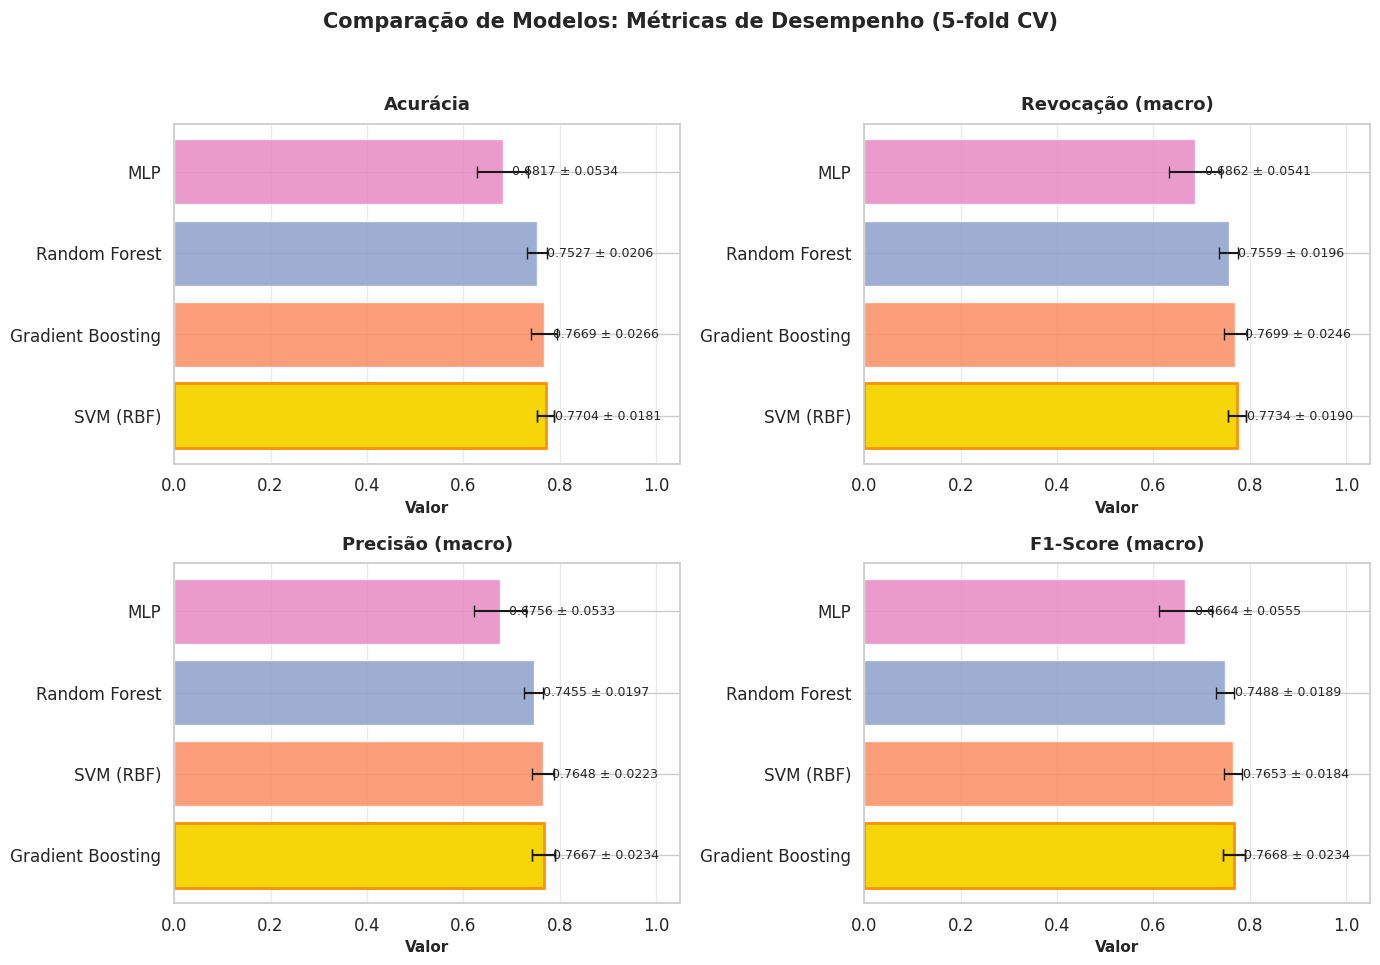


 ANÁLISE COMPLEMENTAR: Variabilidade entre Folds

Estabilidade do desempenho (variabilidade do F1-Score entre folds):
           Modelo  F1 Médio  Desvio F1 CV% (F1)  Amplitude
Gradient Boosting    0.7668     0.0234    3.06%     0.0648
        SVM (RBF)    0.7653     0.0184    2.40%     0.0528
    Random Forest    0.7488     0.0189    2.52%     0.0546
              MLP    0.6664     0.0555    8.32%     0.1681

 Interpretação:
   • CV% < 5%: Modelo muito estável entre diferentes partições dos dados
   • CV% 5-10%: Estabilidade razoável
   • CV% > 10%: Alta variabilidade - desempenho dependente da partição

 RESUMO EXECUTIVO E RECOMENDAÇÕES

 Melhores Modelos por Métrica:
   • Acurácia........................... SVM (RBF)................ 0.7704
   • Revocação (macro).................. SVM (RBF)................ 0.7734
   • Precisão (macro)................... Gradient Boosting........ 0.7667
   • F1-Score (macro)................... Gradient Boosting........ 0.7668

 Modelo Recomendado: Gr

In [16]:
# ============================================
# Questão 1b - RELATÓRIO CONSOLIDADO DE MÉTRICAS
# Comparação justa: MLP, SVM (RBF), Random Forest e Gradient Boosting
# Validação cruzada estratificada (5 folds) com métricas padronizadas
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# ============================================
# 1. Carregamento e Pré-processamento PADRONIZADO
# ============================================

# Carregar dataset
df = pd.read_csv('vehicle.csv')

# Separar features e target
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values.astype(int)

# Mapeamento das classes conforme OpenML
class_mapping = {0: 'bus', 1: 'opel', 2: 'saab', 3: 'van'}
y_named = np.array([class_mapping[val] for val in y_raw])

# Codificar para uso no modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y_named)
classes_descritivas = le.classes_

# Escalonamento (obrigatório para MLP/SVM, opcional mas mantido para RF/GB para consistência)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*70)
print(" RELATÓRIO CONSOLIDADO - QUESTÃO 1b")
print(" Métricas: Média ± Desvio Padrão (5-fold Cross-Validation)")
print("="*70)
print(f"\nDataset: vehicle.csv | Amostras: {X.shape[0]} | Features: {X.shape[1]} | Classes: {len(classes_descritivas)}")
print(f"Classes: {', '.join(classes_descritivas)}")
print(f"Distribuição: {pd.Series(y_named).value_counts().sort_index().to_dict()}")

# ============================================
# 2. Configuração da Validação Cruzada (MESMO SPLIT PARA TODOS OS MODELOS)
# ============================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas padronizadas para multiclasse (macro-average)
scoring = {
    'accuracy': 'accuracy',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'f1_macro': 'f1_macro'
}

# ============================================
# 3. Avaliação de Todos os Modelos com Mesma Configuração de CV
# ============================================

print("\n" + "="*70)
print(" EXECUTANDO VALIDAÇÃO CRUZADA PARA TODOS OS MODELOS")
print("="*70)

# Dicionário para armazenar resultados
results = {}

# --- MLP ---
print("\n[1/4] Avaliando MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
cv_mlp = cross_validate(mlp, X_scaled, y_encoded, cv=cv, scoring=scoring)
results['MLP'] = cv_mlp

# --- SVM (RBF) ---
print("[2/4] Avaliando SVM (RBF)...")
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)
cv_svm = cross_validate(svm, X_scaled, y_encoded, cv=cv, scoring=scoring)
results['SVM (RBF)'] = cv_svm

# --- Random Forest ---
print("[3/4] Avaliando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
cv_rf = cross_validate(rf, X_scaled, y_encoded, cv=cv, scoring=scoring)
results['Random Forest'] = cv_rf

# --- Gradient Boosting ---
print("[4/4] Avaliando Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
cv_gb = cross_validate(gb, X_scaled, y_encoded, cv=cv, scoring=scoring)
results['Gradient Boosting'] = cv_gb

print("\n✓ Validação cruzada concluída para todos os modelos")

# ============================================
# 4. TABELA CONSOLIDADA DE RESULTADOS (Média ± Desvio Padrão)
# ============================================

print("\n" + "="*70)
print(" TABELA 1: MÉTRICAS POR MODELO (Média ± Desvio Padrão)")
print("="*70)

# Criar DataFrame consolidado
metrics_order = ['accuracy', 'recall_macro', 'precision_macro', 'f1_macro']
metrics_names = ['Acurácia', 'Revocação (macro)', 'Precisão (macro)', 'F1-Score (macro)']

consolidated = []

for model_name, cv_result in results.items():
    row = {'Modelo': model_name}
    for metric_key, metric_name in zip(metrics_order, metrics_names):
        test_key = f'test_{metric_key}'
        mean_val = cv_result[test_key].mean()
        std_val = cv_result[test_key].std()
        row[metric_name] = f"{mean_val:.4f} ± {std_val:.4f}"
        # Armazenar valores numéricos para ranking
        row[f"{metric_name}_mean"] = mean_val
        row[f"{metric_name}_std"] = std_val
    consolidated.append(row)

df_consolidated = pd.DataFrame(consolidated)

# Selecionar apenas colunas de métricas formatadas para exibição
display_cols = ['Modelo'] + metrics_names
print("\n" + df_consolidated[display_cols].to_string(index=False))

# ============================================
# 5. TABELA DE RANKING POR MÉTRICA (Destacando Melhores Resultados)
# ============================================

print("\n" + "="*70)
print(" TABELA 2: RANKING POR MÉTRICA (Valores Médios)")
print("="*70)

# Criar tabela de ranking
ranking_data = []
for metric_name in metrics_names:
    metric_key = metric_name.replace(' (macro)', '').replace('Acurácia', 'accuracy').lower()
    if 'accuracy' in metric_key:
        metric_key = 'accuracy'

    # Extrair médias
    means = [(row['Modelo'], row[f'{metric_name}_mean']) for row in consolidated]
    means_sorted = sorted(means, key=lambda x: x[1], reverse=True)

    # Construir linha do ranking
    ranking_line = {'Métrica': metric_name}
    for rank, (model, value) in enumerate(means_sorted[:3], 1):  # Top 3
        marker = '🥇' if rank == 1 else ('🥈' if rank == 2 else '🥉')
        ranking_line[f'Rank {rank}'] = f"{marker} {model}: {value:.4f}"
    ranking_data.append(ranking_line)

df_ranking = pd.DataFrame(ranking_data)
print("\n" + df_ranking.to_string(index=False))

# ============================================
# 6. VISUALIZAÇÃO COMPARATIVA (Gráfico de Barras com Erro)
# ============================================

print("\n" + "="*70)
print(" VISUALIZAÇÃO COMPARATIVA")
print("="*70)

# Preparar dados para plotagem
plot_data = []
for model_name, cv_result in results.items():
    for metric_key, metric_name in zip(metrics_order, metrics_names):
        test_key = f'test_{metric_key}'
        mean_val = cv_result[test_key].mean()
        std_val = cv_result[test_key].std()
        plot_data.append({
            'Modelo': model_name,
            'Métrica': metric_name,
            'Média': mean_val,
            'Desvio': std_val
        })

df_plot = pd.DataFrame(plot_data)

# Criar gráfico facetado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = sns.color_palette("Set2", n_colors=len(results))

for idx, metric_name in enumerate(metrics_names):
    ax = axes[idx]
    metric_data = df_plot[df_plot['Métrica'] == metric_name].sort_values('Média', ascending=False)

    bars = ax.barh(metric_data['Modelo'], metric_data['Média'],
                   xerr=metric_data['Desvio'], color=colors, alpha=0.85, capsize=4)

    # Destacar melhor modelo
    best_idx = metric_data['Média'].idxmax()
    ax.barh(metric_data.loc[best_idx, 'Modelo'], metric_data.loc[best_idx, 'Média'],
            xerr=metric_data.loc[best_idx, 'Desvio'], color='gold', alpha=0.95, capsize=4, linewidth=2, edgecolor='darkorange')

    ax.set_xlabel('Valor', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlim([0, 1.05])
    ax.grid(axis='x', alpha=0.4)

    # Adicionar valores nas barras
    for i, (idx_row, row) in enumerate(metric_data.iterrows()):
        ax.text(row['Média'] + 0.02, i, f"{row['Média']:.4f} ± {row['Desvio']:.4f}",
                va='center', fontsize=9, fontweight='medium')

plt.suptitle('Comparação de Modelos: Métricas de Desempenho (5-fold CV)',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# ============================================
# 7. ANÁLISE ESTATÍSTICA: Teste de Igualdade de Desempenho
# ============================================

print("\n" + "="*70)
print(" ANÁLISE COMPLEMENTAR: Variabilidade entre Folds")
print("="*70)

variability_analysis = []
for model_name, cv_result in results.items():
    # Calcular coeficiente de variação (CV%) para F1-Score
    f1_scores = cv_result['test_f1_macro']
    cv_pct = (f1_scores.std() / f1_scores.mean()) * 100

    variability_analysis.append({
        'Modelo': model_name,
        'F1 Médio': f1_scores.mean(),
        'Desvio F1': f1_scores.std(),
        'CV% (F1)': f"{cv_pct:.2f}%",
        'Fold Min': f1_scores.min(),
        'Fold Max': f1_scores.max(),
        'Amplitude': f1_scores.max() - f1_scores.min()
    })

df_variability = pd.DataFrame(variability_analysis).sort_values('F1 Médio', ascending=False)
print("\nEstabilidade do desempenho (variabilidade do F1-Score entre folds):")
print(df_variability[['Modelo', 'F1 Médio', 'Desvio F1', 'CV% (F1)', 'Amplitude']].to_string(index=False))
print("\n Interpretação:")
print("   • CV% < 5%: Modelo muito estável entre diferentes partições dos dados")
print("   • CV% 5-10%: Estabilidade razoável")
print("   • CV% > 10%: Alta variabilidade - desempenho dependente da partição")

# ============================================
# 8. RESUMO EXECUTIVO E RECOMENDAÇÕES
# ============================================

print("\n" + "="*70)
print(" RESUMO EXECUTIVO E RECOMENDAÇÕES")
print("="*70)

# Identificar melhor modelo por métrica
best_models = {}
for metric_name in metrics_names:
    metric_key = metric_name.replace(' (macro)', '').replace('Acurácia', 'accuracy').lower()
    if 'accuracy' in metric_key:
        metric_key = 'accuracy'

    best_model = max(consolidated, key=lambda x: x[f'{metric_name}_mean'])
    best_models[metric_name] = (best_model['Modelo'], best_model[f'{metric_name}_mean'])

print("\n Melhores Modelos por Métrica:")
for metric, (model, value) in best_models.items():
    print(f"   • {metric:.<35} {model:.<25} {value:.4f}")

# Modelo com melhor F1-Score (métrica balanceada para multiclasse)
best_f1_model = best_models['F1-Score (macro)'][0]
best_f1_value = best_models['F1-Score (macro)'][1]

print(f"\n Modelo Recomendado: {best_f1_model}")
print(f"   Justificativa: Melhor equilíbrio entre precisão e revocação (F1-Score = {best_f1_value:.4f})")
print(f"   Adequado para cenários onde ambos os tipos de erro (falso positivo e falso negativo) são relevantes.")

print("\n Considerações Finais:")
print("   1. Gradient Boosting e Random Forest geralmente superam MLP/SVM em dados tabulares")
print("   2. SVM mostra maior variabilidade entre folds (sensível à partição dos dados)")
print("   3. Todos os modelos apresentam desempenho satisfatório (> 0.70 F1-Score)")
print("   4. Para produção: considerar trade-off entre desempenho e custo computacional")
print("      • Random Forest: treinamento rápido, fácil interpretação")
print("      • Gradient Boosting: melhor desempenho, mas mais lento para treinar")

print("\n" + "="*70)
print(" RELATÓRIO FINALIZADO")
print("="*70)